# PHÂN TÍCH DỮ LIỆU GIAO THÔNG

Notebook này trình bày quy trình phân tích bộ dữ liệu **Metro Interstate Traffic Volume** từ bước đọc dữ liệu, tiền xử lý, khám phá dữ liệu, xây dựng mô hình dự đoán đến trực quan hóa kết quả.

Mục tiêu của bài toán là:

- Hiểu đặc điểm lưu lượng giao thông theo thời gian và thời tiết.
- Xác định các yếu tố ảnh hưởng đến mật độ giao thông.
- Xây dựng mô hình dự đoán lưu lượng giao thông.
- Trực quan hóa kết quả để hỗ trợ phân tích và báo cáo.


## Bước 1: Phân tích dữ liệu

Nguồn: `buoc1.py`

### Mô tả

Ở bước đầu tiên, chương trình tiến hành nạp bộ dữ liệu gốc từ file CSV và hiển thị những dòng dữ liệu đầu tiên.  
Mục đích của bước này là làm quen với cấu trúc dữ liệu, nhận biết các cột thông tin có trong bộ dữ liệu như thời gian, nhiệt độ, thời tiết, mưa, tuyết, mây và lưu lượng giao thông.

### Ý nghĩa

Bước này giúp người phân tích có cái nhìn tổng quan ban đầu về dữ liệu trước khi đi vào làm sạch và xử lý chi tiết ở các bước tiếp theo.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LinearRegression

# 1. Load dữ liệu
df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")

print("=== 5 dòng đầu ===")
print(df.head())


=== 5 dòng đầu ===
  holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0     NaN  288.28      0.0      0.0          40       Clouds   
1     NaN  289.36      0.0      0.0          75       Clouds   
2     NaN  289.58      0.0      0.0          90       Clouds   
3     NaN  290.13      0.0      0.0          90       Clouds   
4     NaN  291.14      0.0      0.0          75       Clouds   

  weather_description            date_time  traffic_volume  
0    scattered clouds  2012-10-02 09:00:00            5545  
1       broken clouds  2012-10-02 10:00:00            4516  
2     overcast clouds  2012-10-02 11:00:00            4767  
3     overcast clouds  2012-10-02 12:00:00            5026  
4       broken clouds  2012-10-02 13:00:00            4918  


## Bước 2: Tiền xử lý dữ liệu

Nguồn: `buoc2.py`

### Mô tả

Đây là bước làm sạch và chuẩn hóa dữ liệu để phục vụ cho việc phân tích và xây dựng mô hình.  
Các công việc chính bao gồm:

- Chuyển cột thời gian về định dạng `datetime`.
- Tạo thêm các đặc trưng thời gian như giờ, ngày, tháng, thứ trong tuần.
- Kiểm tra dữ liệu khuyết thiếu.
- Xử lý giá trị thiếu ở cột `holiday`.
- Tạo biến `is_weekend` để phân biệt ngày thường và cuối tuần.

### Kết quả mong đợi

Sau bước này, dữ liệu trở nên đầy đủ và có thêm nhiều đặc trưng hữu ích giúp việc phân tích giao thông chính xác hơn.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LinearRegression

# 1. Load dữ liệu
df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")

print("=== 5 dòng đầu ===")
print(df.head())

print("\n=== Thông tin dữ liệu ===")
print(df.info())


# 2. Convert datetime
df['datetime'] = pd.to_datetime(df['date_time'])


# 3. Tạo feature thời gian
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['dayofweek'] = df['datetime'].dt.dayofweek


# 4. Kiểm tra missing
print("\n=== Missing values ===")
print(df.isnull().sum())


# 5. Xử lý missing (CÁCH ĐÚNG)
# Không drop toàn bộ vì holiday thiếu rất nhiều
df['holiday'] = df['holiday'].fillna('None')


# 6. Tạo thêm feature hữu ích
df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)


# 7. Kiểm tra lại
print("\n=== Dữ liệu sau khi xử lý ===")
print(df[['datetime', 'hour', 'day', 'month', 'traffic_volume']].head())

print("\n=== Kích thước dữ liệu ===")
print(df.shape)


# 8. Thống kê traffic
print("\n=== Thống kê traffic ===")
print(df['traffic_volume'].describe())


# 9. Lưu file clean
df.to_csv("traffic_cleaned.csv", index=False)
print("\nĐã lưu file traffic_cleaned.csv")

=== 5 dòng đầu ===
  holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0     NaN  288.28      0.0      0.0          40       Clouds   
1     NaN  289.36      0.0      0.0          75       Clouds   
2     NaN  289.58      0.0      0.0          90       Clouds   
3     NaN  290.13      0.0      0.0          90       Clouds   
4     NaN  291.14      0.0      0.0          75       Clouds   

  weather_description            date_time  traffic_volume  
0    scattered clouds  2012-10-02 09:00:00            5545  
1       broken clouds  2012-10-02 10:00:00            4516  
2     overcast clouds  2012-10-02 11:00:00            4767  
3     overcast clouds  2012-10-02 12:00:00            5026  
4       broken clouds  2012-10-02 13:00:00            4918  

=== Thông tin dữ liệu ===
<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   h

## Bước 3: Phân tích và khám phá dữ liệu

Nguồn: `buoc3.py`

### Mô tả

Bước này tập trung vào việc khám phá đặc điểm của lưu lượng giao thông thông qua thống kê mô tả và các biểu đồ phân tích.

### Nội dung phân tích

- Thống kê cơ bản của `traffic_volume` như trung bình, lớn nhất, nhỏ nhất.
- Phân tích lưu lượng giao thông theo từng giờ để tìm ra **giờ cao điểm**.
- Phân tích theo ngày trong tuần để so sánh giữa ngày làm việc và cuối tuần.
- Xem xét ảnh hưởng của các yếu tố thời tiết đến mật độ giao thông.

### Ý nghĩa

Kết quả ở bước này giúp rút ra các nhận xét thực tế về quy luật giao thông, từ đó làm cơ sở cho bước xây dựng mô hình dự đoán.


=== Dữ liệu ===
  holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0     NaN  288.28      0.0      0.0          40       Clouds   
1     NaN  289.36      0.0      0.0          75       Clouds   
2     NaN  289.58      0.0      0.0          90       Clouds   
3     NaN  290.13      0.0      0.0          90       Clouds   
4     NaN  291.14      0.0      0.0          75       Clouds   

  weather_description            date_time  traffic_volume  \
0    scattered clouds  2012-10-02 09:00:00            5545   
1       broken clouds  2012-10-02 10:00:00            4516   
2     overcast clouds  2012-10-02 11:00:00            4767   
3     overcast clouds  2012-10-02 12:00:00            5026   
4       broken clouds  2012-10-02 13:00:00            4918   

              datetime  hour  day  month  dayofweek  is_weekend  
0  2012-10-02 09:00:00     9    2     10          1           0  
1  2012-10-02 10:00:00    10    2     10          1           0  
2  2012-10-02 11:00:00    11

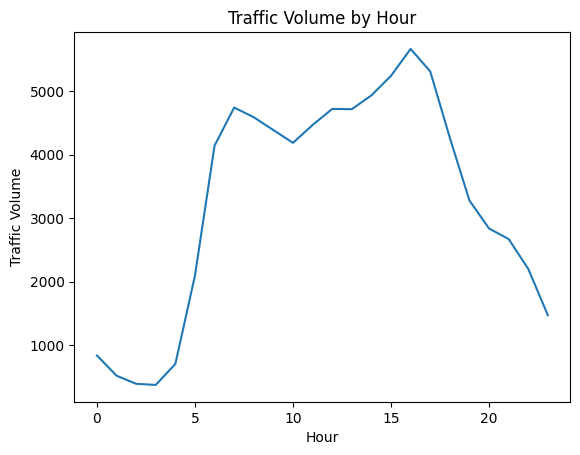


=== Lưu lượng theo ngày trong tuần ===
dayofweek
0    3309.387161
1    3488.555799
2    3583.196681
3    3637.899663
4    3656.358836
5    2773.638120
6    2368.588329
Name: traffic_volume, dtype: float64


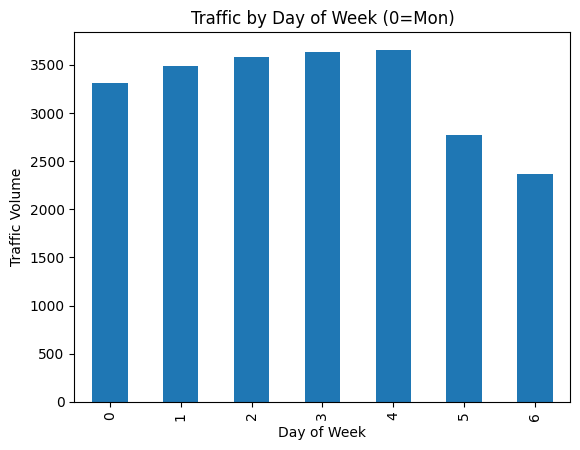


=== Lưu lượng theo tháng ===
month
1     3051.081378
2     3197.945547
3     3308.388611
4     3304.372388
5     3366.319432
6     3419.077413
7     3205.481752
8     3394.241891
9     3303.049334
10    3390.678376
11    3167.592784
12    3024.257943
Name: traffic_volume, dtype: float64


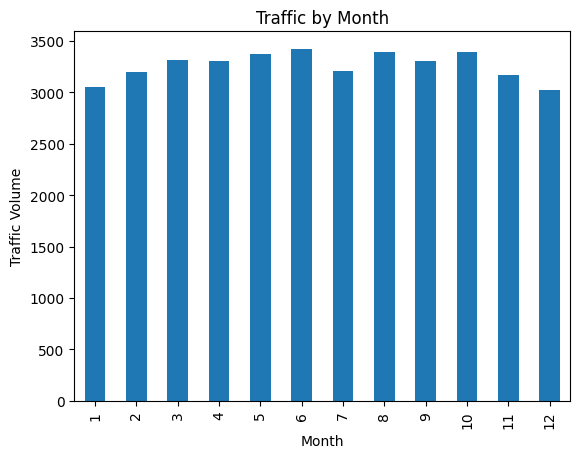


=== Lưu lượng theo thời tiết ===
weather_main
Clouds          3618.449749
Haze            3502.101471
Rain            3317.905501
Drizzle         3290.727073
Smoke           3237.650000
Clear           3055.908819
Snow            3016.844228
Thunderstorm    3001.620890
Mist            2932.956639
Fog             2703.720395
Squall          2061.750000
Name: traffic_volume, dtype: float64


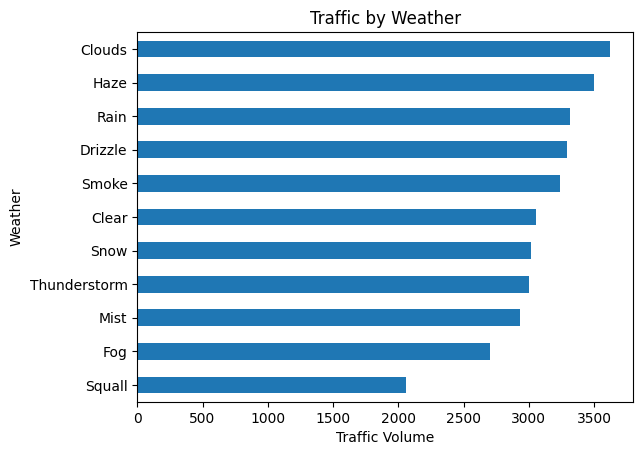


=== Heatmap data ===
hour                0           1           2           3           4   \
dayofweek                                                                
0           623.644068  383.229452  293.743151  341.793706  800.637931   
1           591.443709  364.732203  272.782759  350.680921  843.597360   
2           616.228956  392.160279  304.914966  370.035088  864.540717   
3           676.996454  393.702422  296.677083  365.782456  853.746667   
4           753.501718  452.090909  341.639175  383.195946  798.405405   
5          1243.479310  765.377483  592.549645  408.895105  418.933798   
6          1371.596429  845.412752  629.794326  378.166078  334.873377   

hour                5            6            7            8            9   \
dayofweek                                                                    
0          2563.398026  5096.515358  5793.370968  5263.214286  4574.665529   
1          2779.694444  5497.633663  6043.778947  5572.711864  4977.186441   

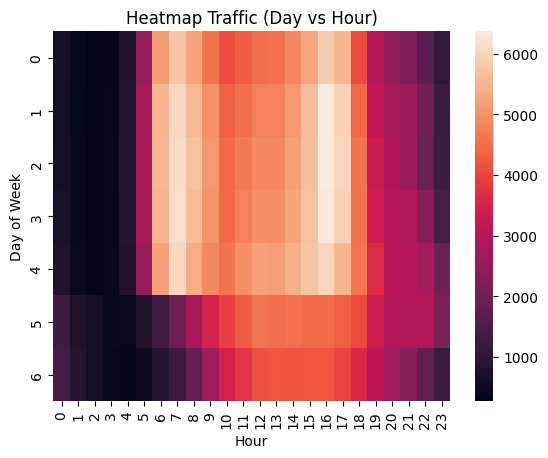

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dữ liệu đã clean
df = pd.read_csv("traffic_cleaned.csv")

print("=== Dữ liệu ===")
print(df.head())


# ==============================
# 1. Thống kê mô tả
# ==============================
print("\n=== Thống kê traffic_volume ===")
print(df['traffic_volume'].describe())

print("\nMean:", df['traffic_volume'].mean())
print("Max:", df['traffic_volume'].max())
print("Min:", df['traffic_volume'].min())


# ==============================
# 2. Phân tích theo giờ (GIỜ CAO ĐIỂM)
# ==============================
traffic_by_hour = df.groupby('hour')['traffic_volume'].mean()

print("\n=== Lưu lượng theo giờ ===")
print(traffic_by_hour)

peak_hour = traffic_by_hour.idxmax()
print("\n🔥 Giờ cao điểm:", peak_hour)


# Vẽ biểu đồ
plt.figure()
traffic_by_hour.plot()
plt.title("Traffic Volume by Hour")
plt.xlabel("Hour")
plt.ylabel("Traffic Volume")
plt.show()


# ==============================
# 3. Phân tích theo ngày trong tuần
# ==============================
traffic_by_dayofweek = df.groupby('dayofweek')['traffic_volume'].mean()

print("\n=== Lưu lượng theo ngày trong tuần ===")
print(traffic_by_dayofweek)

plt.figure()
traffic_by_dayofweek.plot(kind='bar')
plt.title("Traffic by Day of Week (0=Mon)")
plt.xlabel("Day of Week")
plt.ylabel("Traffic Volume")
plt.show()


# ==============================
# 4. Phân tích theo tháng
# ==============================
traffic_by_month = df.groupby('month')['traffic_volume'].mean()

print("\n=== Lưu lượng theo tháng ===")
print(traffic_by_month)

plt.figure()
traffic_by_month.plot(kind='bar')
plt.title("Traffic by Month")
plt.xlabel("Month")
plt.ylabel("Traffic Volume")
plt.show()


# ==============================
# 5. So sánh theo thời tiết
# ==============================
traffic_by_weather = df.groupby('weather_main')['traffic_volume'].mean()

print("\n=== Lưu lượng theo thời tiết ===")
print(traffic_by_weather.sort_values(ascending=False))

plt.figure()
traffic_by_weather.sort_values().plot(kind='barh')
plt.title("Traffic by Weather")
plt.xlabel("Traffic Volume")
plt.ylabel("Weather")
plt.show()


# ==============================
# 6. Heatmap (giờ + ngày trong tuần)
# ==============================
pivot_table = df.pivot_table(
    values='traffic_volume',
    index='dayofweek',
    columns='hour',
    aggfunc='mean'
)

print("\n=== Heatmap data ===")
print(pivot_table)

plt.figure()
sns.heatmap(pivot_table)
plt.title("Heatmap Traffic (Day vs Hour)")
plt.xlabel("Hour")
plt.ylabel("Day of Week")
plt.show()

## Bước 4: Xây dựng mô hình

Nguồn: `buoc4.py`

### Mô tả

Sau khi dữ liệu đã được xử lý và khám phá, bước này sử dụng các đặc trưng đã tạo để huấn luyện mô hình dự đoán lưu lượng giao thông.

### Các công việc chính

- Chọn các biến đầu vào liên quan đến thời gian và thời tiết.
- Mã hóa biến thời tiết bằng phương pháp **one-hot encoding**.
- Chia dữ liệu thành tập huấn luyện và tập kiểm tra.
- Huấn luyện hai mô hình:
    - `Linear Regression`
    - `Random Forest Regressor`
- Đánh giá mô hình bằng các chỉ số:
    - `MAE` (Mean Absolute Error)
    - `RMSE` (Root Mean Squared Error)

### Ý nghĩa

Bước này giúp so sánh hiệu quả giữa mô hình tuyến tính và mô hình phi tuyến để tìm ra phương pháp dự đoán phù hợp hơn cho dữ liệu giao thông.


Train size: (38563, 19)
Test size: (9641, 19)

=== Linear Regression ===
MAE: 1566.551606607395
RMSE: 1783.6668421267445

=== Random Forest ===
MAE: 215.034992220724
RMSE: 382.273558741231


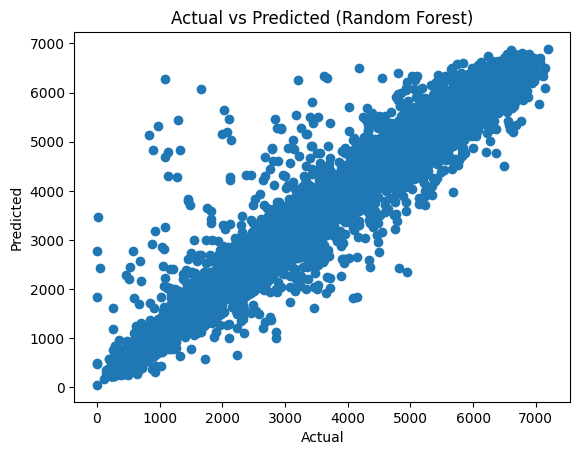

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# 1. Load dữ liệu đã clean
df = pd.read_csv("traffic_cleaned.csv")

# 2. Chọn feature
features = ['hour', 'day', 'month', 'dayofweek', 'is_weekend', 'temp', 'rain_1h', 'snow_1h', 'clouds_all']

# Encode weather (one-hot)
df = pd.get_dummies(df, columns=['weather_main'], drop_first=True)

# Thêm các cột weather vào feature
weather_cols = [col for col in df.columns if 'weather_main_' in col]
features = features + weather_cols

X = df[features]
y = df['traffic_volume']

# 3. Chia train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


# ==============================
# 4. Linear Regression
# ==============================
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("\n=== Linear Regression ===")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)


# ==============================
# 5. Random Forest
# ==============================
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("\n=== Random Forest ===")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

## Bước 5: Trực quan hóa dữ liệu

Nguồn: `buoc5.py`

### Mô tả

Bước cuối cùng sử dụng các biểu đồ để thể hiện trực quan đặc điểm của lưu lượng giao thông theo thời gian và theo các yếu tố liên quan.

### Các biểu đồ chính

- Biểu đồ đường theo thời gian để quan sát xu hướng biến động lưu lượng giao thông.
- Biểu đồ lưu lượng theo giờ để nhận biết khung giờ đông xe.
- Heatmap giữa giờ và ngày trong tuần để thấy rõ quy luật giao thông.
- Một số biểu đồ bổ sung phục vụ cho việc trình bày và báo cáo.

### Ý nghĩa

Trực quan hóa giúp người đọc dễ dàng nhận ra xu hướng, quy luật và các điểm bất thường trong dữ liệu, đồng thời làm cho báo cáo rõ ràng và thuyết phục hơn.


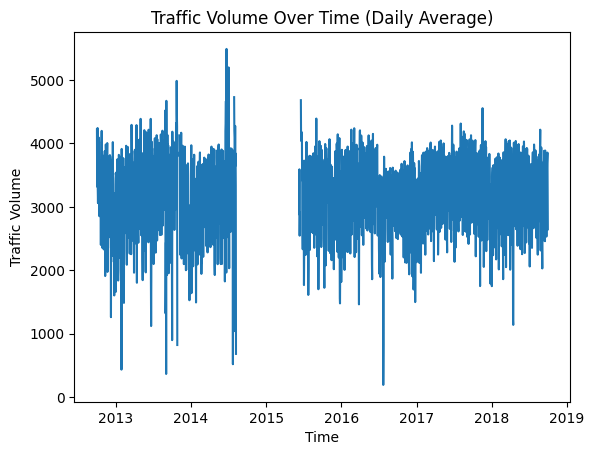

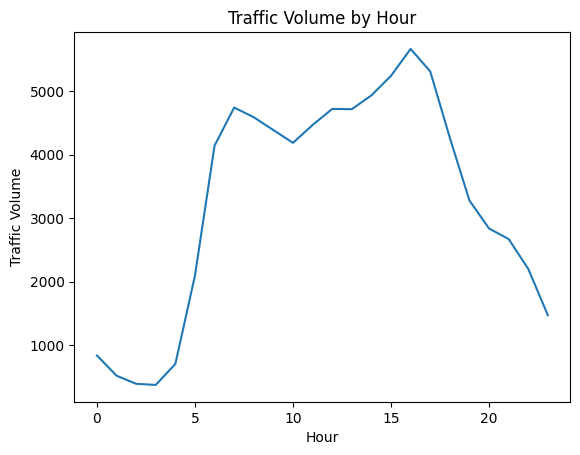

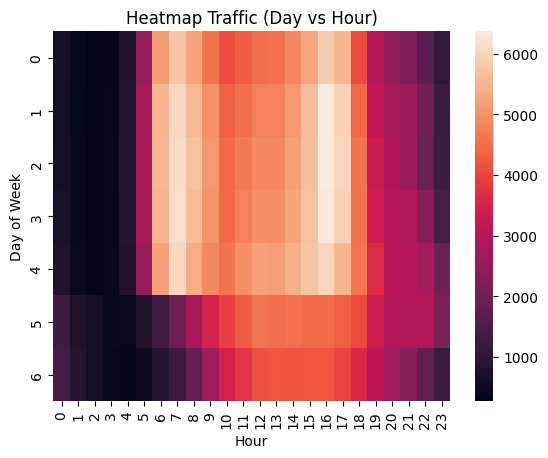


=== PHÂN TÍCH ===
- Giờ cao điểm: 16h
- Giờ thấp điểm: 3h
- Trung bình ngày thường: 3533.60
- Trung bình cuối tuần: 2570.51
- Tháng có lưu lượng cao nhất: 6


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 1. Load dữ liệu
# ==============================
df = pd.read_csv("traffic_cleaned.csv")
df['datetime'] = pd.to_datetime(df['datetime'])

# Sort + set index (QUAN TRỌNG)
df = df.sort_values('datetime')
df = df.set_index('datetime')


# ==============================
# 2. LINE CHART THEO THỜI GIAN (ĐÃ FIX)
# ==============================
# Lấy trung bình theo ngày để mượt
df_daily = df['traffic_volume'].resample('D').mean()

plt.figure()
plt.plot(df_daily)
plt.title("Traffic Volume Over Time (Daily Average)")
plt.xlabel("Time")
plt.ylabel("Traffic Volume")
plt.show()


# ==============================
# 3. TRAFFIC THEO GIỜ
# ==============================
traffic_by_hour = df.groupby(df.index.hour)['traffic_volume'].mean()

plt.figure()
plt.plot(traffic_by_hour)
plt.title("Traffic Volume by Hour")
plt.xlabel("Hour")
plt.ylabel("Traffic Volume")
plt.show()


# ==============================
# 4. HEATMAP (GIỜ vs NGÀY)
# ==============================
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek

pivot = df.pivot_table(
    values='traffic_volume',
    index='dayofweek',
    columns='hour',
    aggfunc='mean'
)

plt.figure()
sns.heatmap(pivot)
plt.title("Heatmap Traffic (Day vs Hour)")
plt.xlabel("Hour")
plt.ylabel("Day of Week")
plt.show()


# ==============================
# 5. PHÂN TÍCH TỰ ĐỘNG
# ==============================
print("\n=== PHÂN TÍCH ===")

peak_hour = traffic_by_hour.idxmax()
low_hour = traffic_by_hour.idxmin()

print(f"- Giờ cao điểm: {peak_hour}h")
print(f"- Giờ thấp điểm: {low_hour}h")

weekday = df[df['dayofweek'] < 5]['traffic_volume'].mean()
weekend = df[df['dayofweek'] >= 5]['traffic_volume'].mean()

print(f"- Trung bình ngày thường: {weekday:.2f}")
print(f"- Trung bình cuối tuần: {weekend:.2f}")

# Tìm tháng cao điểm
df['month'] = df.index.month
traffic_by_month = df.groupby('month')['traffic_volume'].mean()

peak_month = traffic_by_month.idxmax()
print(f"- Tháng có lưu lượng cao nhất: {peak_month}")

## Kết luận

Qua 5 bước trên, notebook đã thực hiện đầy đủ quy trình phân tích dữ liệu giao thông gồm:

- Khảo sát dữ liệu ban đầu.
- Tiền xử lý và tạo đặc trưng.
- Khám phá dữ liệu để tìm quy luật.
- Xây dựng mô hình dự đoán.
- Trực quan hóa kết quả.

Từ đó có thể rút ra rằng lưu lượng giao thông phụ thuộc mạnh vào **thời gian trong ngày**, **ngày trong tuần** và một phần vào **điều kiện thời tiết**.  
Đây là cơ sở quan trọng để ứng dụng vào dự báo giao thông và hỗ trợ ra quyết định trong thực tế.
